Importing required data science libraries (Pandas, NumPy, Matplotlib) and configuring inline plotting.

Импорт необходимых библиотек для обработки данных (Pandas, NumPy, Matplotlib) и настройка встроенного построения графиков.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import kagglehub as kh
from os import environ
%matplotlib inline

Reading the credits and titles datasets from CSV files and configuring the display settings.

Считывание наборов данных credits и titles из CSV-файлов и настройка параметров отображения.

In [2]:
environ["KAGGLEHUB_ANONYMOUS_DOWNLOAD"]='1'
filepath=kh.dataset_download("victorsoeiro/netflix-tv-shows-and-movies")
df1=pd.read_csv(f"{filepath}/credits.csv", encoding='utf-8')
df2=pd.read_csv(f"{filepath}/titles.csv", encoding='utf-8')
pd.set_option('display.max_colwidth', 50)

100%|██████████| 2.25M/2.25M [00:00<00:00, 21.6MB/s]

Extracting files...


Checking the structure, data types, dimensions, and the first 10 rows of the credits dataset.

Проверка структуры, типов данных, измерений и первых 10 строк набора данных credits.

In [3]:
df1.info(memory_usage='deep')
print(df1.shape)
display(df1.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77801 entries, 0 to 77800
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  77801 non-null  int64 
 1   id         77801 non-null  object
 2   name       77801 non-null  object
 3   character  68029 non-null  object
 4   role       77801 non-null  object
dtypes: int64(1), object(4)
memory usage: 17.9 MB
(77801, 5)


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,ACTOR
1,14658,tm84618,Jodie Foster,Iris Steensma,ACTOR
2,7064,tm84618,Albert Brooks,Tom,ACTOR
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,ACTOR
4,48933,tm84618,Cybill Shepherd,Betsy,ACTOR
5,32267,tm84618,Peter Boyle,Wizard,ACTOR
6,519612,tm84618,Leonard Harris,Senator Charles Palantine,ACTOR
7,29068,tm84618,Diahnne Abbott,Concession Girl,ACTOR
8,519613,tm84618,Gino Ardito,Policeman at Rally,ACTOR
9,3308,tm84618,Martin Scorsese,Passenger Watching Silhouette,ACTOR


Finding all unique values in the "role" column to identify crew classifications.

Поиск всех уникальных значений в столбце "role" для определения классификаций экипажей.

In [4]:
print(df1['role'].unique().tolist())

['ACTOR', 'DIRECTOR']


Checking for missing values and duplicate rows across the credits dataset.

In [5]:
print(df1.isna().sum())
print(df1.duplicated().sum())

person_id       0
id              0
name            0
character    9772
role            0
dtype: int64
0


Analyzing missing character values specifically for directors and actors.

Анализ недостающих характеристик персонажей специально для режиссеров и актеров.

In [6]:
print(df1[df1['role']=='DIRECTOR']['character'].isna().sum())
print(df1[df1['role']=='ACTOR']['character'].isna().sum())

4550
5222


Cleaning data by filling missing characters for directors, dropping nulls, optimizing data types, and converting roles to title case.

Очистка данных путем заполнения недостающих символов для директоров, удаления нулевых значений, оптимизации типов данных и преобразования ролей в соответствии с регистром заголовков.

In [7]:
df1[df1['role']=='DIRECTOR']=df1[df1['role']=='DIRECTOR'].fillna('-')
df1=df1.dropna()
df1['person_id']=df1['person_id'].astype('int32')
df1['role']=df1['role'].str.title()
df1.index=np.arange(0, len(df1))
df1.info(memory_usage='deep')
display(df1.head(10))

<class 'pandas.core.frame.DataFrame'>
Index: 72579 entries, 0 to 72578
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  72579 non-null  int32 
 1   id         72579 non-null  object
 2   name       72579 non-null  object
 3   character  72579 non-null  object
 4   role       72579 non-null  object
dtypes: int32(1), object(4)
memory usage: 17.2 MB


,person_id,id,name,character,role
0,3748,tm84618,Robert De Niro,Travis Bickle,Actor
1,14658,tm84618,Jodie Foster,Iris Steensma,Actor
2,7064,tm84618,Albert Brooks,Tom,Actor
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,Actor
4,48933,tm84618,Cybill Shepherd,Betsy,Actor
5,32267,tm84618,Peter Boyle,Wizard,Actor
6,519612,tm84618,Leonard Harris,Senator Charles Palantine,Actor
7,29068,tm84618,Diahnne Abbott,Concession Girl,Actor
8,519613,tm84618,Gino Ardito,Policeman at Rally,Actor
9,3308,tm84618,Martin Scorsese,Passenger Watching Silhouette,Actor


Checking for duplicate records based on identical title ID, person name, character, and role.

Проверка наличия повторяющихся записей на основе идентичного идентификатора должности, имени человека, персонажа и роли.

In [8]:
print(df1[['id', 'name', 'character', 'role']].duplicated().sum())
display(df1[df1.duplicated(subset=['id', 'name', 'character', 'role'], keep=False)])

5


,person_id,id,name,character,role
7333,1351325,tm88045,Philip Greene,Baseball Fan (uncredited),Actor
7334,231644,tm88045,Philip Greene,Baseball Fan (uncredited),Actor
14054,605507,tm160371,Dan Levy,Reporter,Actor
14064,197736,tm160371,Dan Levy,Reporter,Actor
18326,725245,ts67797,Nicolas Le Nevé,-,Director
18327,725246,ts67797,Nicolas Le Nevé,-,Director
21695,590023,ts42090,John Iii Franklin,Himself,Actor
21697,590025,ts42090,John Iii Franklin,Himself,Actor
28373,2301299,ts82526,Claudio Roca,Nicolás,Actor
28374,2076922,ts82526,Claudio Roca,Nicolás,Actor


Verifying ID uniqueness by checking if any person ID is associated with multiple unique names.

Проверка уникальности идентификатора осуществляется путем проверки того, связан ли какой-либо идентификатор пользователя с несколькими уникальными именами.

In [9]:
test1=df1.groupby('person_id', as_index=False)['name'].nunique()
print(test1[test1['name']>1].count())

person_id    0
name         0
dtype: int64


Inspecting specific rows for actors with duplicate ID issues.

Проверка определенных строк на предмет наличия у участников проблем с дублированием идентификаторов.

In [10]:
display(df1[df1['name']=='Dan Levy'])
display(df1[df1['name']=='Philip Greene'])
display(df1[df1['name']=='John Iii Franklin'])
display(df1[df1['name']=='Claudio Roca'])

,person_id,id,name,character,role
14054,605507,tm160371,Dan Levy,Reporter,Actor
14064,197736,tm160371,Dan Levy,Reporter,Actor
19384,605507,ts21867,Dan Levy,David Rose,Actor
52963,605507,tm884369,Dan Levy,Self,Actor


,person_id,id,name,character,role
7333,1351325,tm88045,Philip Greene,Baseball Fan (uncredited),Actor
7334,231644,tm88045,Philip Greene,Baseball Fan (uncredited),Actor


,person_id,id,name,character,role
21695,590023,ts42090,John Iii Franklin,Himself,Actor
21696,590024,ts42090,John Iii Franklin,Herself,Actor
21697,590025,ts42090,John Iii Franklin,Himself,Actor


,person_id,id,name,character,role
17687,2076922,ts37187,Claudio Roca,Álvaro “el tequita” Martínez,Actor
28373,2301299,ts82526,Claudio Roca,Nicolás,Actor
28374,2076922,ts82526,Claudio Roca,Nicolás,Actor


Removing the identified duplicate rows from the credits dataset.

Удаление идентифицированных повторяющихся строк из набора данных credits.

In [11]:
df1=df1.drop(index=[13498, 7082, 20721, 20722, 26989])
print(df1[['id', 'name', 'character', 'role']].duplicated().sum())
df1.info(memory_usage='deep')

5
<class 'pandas.core.frame.DataFrame'>
Index: 72574 entries, 0 to 72578
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  72574 non-null  int32 
 1   id         72574 non-null  object
 2   name       72574 non-null  object
 3   character  72574 non-null  object
 4   role       72574 non-null  object
dtypes: int32(1), object(4)
memory usage: 17.2 MB


Inspecting the structure, dimensions, and the first 10 rows of the titles dataset.

Проверяем структуру, размеры и первые 10 строк набора данных titles.

In [12]:
df2.info(memory_usage='deep')
print(df2.shape)
display(df2.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5850 non-null   object 
 1   title                 5849 non-null   object 
 2   type                  5850 non-null   object 
 3   description           5832 non-null   object 
 4   release_year          5850 non-null   int64  
 5   age_certification     3231 non-null   object 
 6   runtime               5850 non-null   int64  
 7   genres                5850 non-null   object 
 8   production_countries  5850 non-null   object 
 9   seasons               2106 non-null   float64
 10  imdb_id               5447 non-null   object 
 11  imdb_score            5368 non-null   float64
 12  imdb_votes            5352 non-null   float64
 13  tmdb_popularity       5759 non-null   float64
 14  tmdb_score            5539 non-null   float64
dtypes: float64(5), int64(

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,['documentation'],['US'],1.0,NaN,NaN,NaN,0.600,NaN
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"['drama', 'crime']",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"['drama', 'action', 'thriller', 'european']",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"['fantasy', 'action', 'comedy']",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"['war', 'action']","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600
5,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,"['comedy', 'european']",['GB'],4.0,tt0063929,8.8,73424.0,17.617,8.306
6,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,['comedy'],['GB'],NaN,tt0079470,8.0,395024.0,17.770,7.800
7,tm14873,Dirty Harry,MOVIE,When a madman dubbed 'Scorpio' terrorizes San ...,1971,R,102,"['thriller', 'action', 'crime']",['US'],NaN,tt0066999,7.7,155051.0,12.817,7.500
8,tm119281,Bonnie and Clyde,MOVIE,"In the 1930s, bored waitress Bonnie Parker fal...",1967,R,110,"['crime', 'drama', 'action']",['US'],NaN,tt0061418,7.7,112048.0,15.687,7.500
9,tm98978,The Blue Lagoon,MOVIE,Two small children and a ship's cook survive a...,1980,R,104,"['romance', 'action', 'drama']",['US'],NaN,tt0080453,5.8,69844.0,50.324,6.156


Counting missing values and checking for exact duplicate rows in the titles dataset.

Подсчет пропущенных значений и проверка наличия точных дубликатов строк в наборе данных titles.

In [13]:
print(df2.isna().sum())
print(df2.duplicated().sum())

id                         0
title                      1
type                       0
description               18
release_year               0
age_certification       2619
runtime                    0
genres                     0
production_countries       0
seasons                 3744
imdb_id                  403
imdb_score               482
imdb_votes               498
tmdb_popularity           91
tmdb_score               311
dtype: int64
0


Preprocessing titles by dropping rows with missing titles, filling empty text/IDs, replacing numerical NaNs with 0, and formatting genres.

Предварительная обработка заголовков путем удаления строк с пропущенными заголовками, заполнения пустого текста / идентификаторов, замены числовых значений N на 0 и форматирования жанров.

In [14]:
df2=df2.dropna(subset='title')
df2['imdb_id']=df2['imdb_id'].fillna('Unknown')
df2['description']=df2['description'].fillna('No description available')
group_columns=['imdb_score', 'imdb_votes', 'tmdb_popularity', 'tmdb_score']
df2[group_columns]=df2[group_columns].fillna(0)
df2[['runtime', 'release_year']]=df2[['runtime', 'release_year']].astype('int32')
df2['genres']=df2['genres'].str.replace('[', '').str.replace(']', '').str.replace('\'', '').str.title()
display(df2.head(10))

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,Documentation,['US'],1.0,Unknown,0.0,0.0,0.600,0.000
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"Drama, Crime",['US'],NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"Drama, Action, Thriller, European",['US'],NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"Fantasy, Action, Comedy",['GB'],NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"War, Action","['GB', 'US']",NaN,tt0061578,7.7,72662.0,20.398,7.600
5,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,"Comedy, European",['GB'],4.0,tt0063929,8.8,73424.0,17.617,8.306
6,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,Comedy,['GB'],NaN,tt0079470,8.0,395024.0,17.770,7.800
7,tm14873,Dirty Harry,MOVIE,When a madman dubbed 'Scorpio' terrorizes San ...,1971,R,102,"Thriller, Action, Crime",['US'],NaN,tt0066999,7.7,155051.0,12.817,7.500
8,tm119281,Bonnie and Clyde,MOVIE,"In the 1930s, bored waitress Bonnie Parker fal...",1967,R,110,"Crime, Drama, Action",['US'],NaN,tt0061418,7.7,112048.0,15.687,7.500
9,tm98978,The Blue Lagoon,MOVIE,Two small children and a ship's cook survive a...,1980,R,104,"Romance, Action, Drama",['US'],NaN,tt0080453,5.8,69844.0,50.324,6.156


Cleaning and extracting a unique list of country codes from the production countries column.

Очистка и извлечение уникального списка кодов стран из столбца страны производства.

In [15]:
countries=df2['production_countries'].unique().tolist()
countries=', '.join(countries)
countries=countries.replace('[', '').replace(']', '').replace('\"', '').replace('\'', '')
countries=set(countries.split(', '))
countries=list(countries)
countries.sort()
print(countries)
print(len(countries))

['', 'AE', 'AF', 'AL', 'AO', 'AR', 'AT', 'AU', 'BD', 'BE', 'BF', 'BG', 'BR', 'BS', 'BT', 'BY', 'CA', 'CD', 'CH', 'CL', 'CM', 'CN', 'CO', 'CU', 'CY', 'CZ', 'DE', 'DK', 'DZ', 'EG', 'ES', 'FI', 'FO', 'FR', 'GB', 'GE', 'GH', 'GL', 'GR', 'GT', 'HK', 'HR', 'HU', 'ID', 'IE', 'IL', 'IN', 'IO', 'IQ', 'IR', 'IS', 'IT', 'JO', 'JP', 'KE', 'KG', 'KH', 'KN', 'KR', 'KW', 'LB', 'LK', 'LT', 'LU', 'Lebanon', 'MA', 'MC', 'MT', 'MU', 'MW', 'MX', 'MY', 'NA', 'NG', 'NL', 'NO', 'NP', 'NZ', 'PE', 'PH', 'PK', 'PL', 'PR', 'PS', 'PT', 'PY', 'QA', 'RO', 'RS', 'RU', 'SA', 'SE', 'SG', 'SN', 'SU', 'SY', 'TH', 'TN', 'TR', 'TW', 'TZ', 'UA', 'US', 'UY', 'VA', 'VE', 'VN', 'XX', 'ZA', 'ZW']
110


Defining a dictionary to map ISO country codes to full country names.

Определение словаря для сопоставления кодов стран ISO с полными названиями стран.

In [16]:
countries_dict = {
    "": "Unknown Region",
    "AE": "United Arab Emirates",
    "AF": "Afghanistan",
    "AL": "Albania",
    "AO": "Angola",
    "AR": "Argentina",
    "AT": "Austria",
    "AU": "Australia",
    "BD": "Bangladesh",
    "BE": "Belgium",
    "BF": "Burkina Faso",
    "BG": "Bulgaria",
    "BR": "Brazil",
    "BS": "Bahamas",
    "BT": "Bhutan",
    "BY": "Belarus",
    "CA": "Canada",
    "CD": "Democratic Republic of the Congo",
    "CH": "Switzerland",
    "CL": "Chile",
    "CM": "Cameroon",
    "CN": "China",
    "CO": "Colombia",
    "CU": "Cuba",
    "CY": "Cyprus",
    "CZ": "Czechia",
    "DE": "Germany",
    "DK": "Denmark",
    "DZ": "Algeria",
    "EG": "Egypt",
    "ES": "Spain",
    "FI": "Finland",
    "FO": "Faroe Islands",
    "FR": "France",
    "GB": "United Kingdom",
    "GE": "Georgia",
    "GH": "Ghana",
    "GL": "Greenland",
    "GR": "Greece",
    "GT": "Guatemala",
    "HK": "Hong Kong",
    "HR": "Croatia",
    "HU": "Hungary",
    "ID": "Indonesia",
    "IE": "Ireland",
    "IL": "Israel",
    "IN": "India",
    "IO": "British Indian Ocean Territory",
    "IQ": "Iraq",
    "IR": "Iran",
    "IS": "Iceland",
    "IT": "Italy",
    "JO": "Jordan",
    "JP": "Japan",
    "KE": "Kenya",
    "KG": "Kyrgyzstan",
    "KH": "Cambodia",
    "KN": "Saint Kitts and Nevis",
    "KR": "South Korea",
    "KW": "Kuwait",
    "LB": "Lebanon",
    "LK": "Sri Lanka",
    "LT": "Lithuania",
    "LU": "Luxembourg",
    "Lebanon": "Lebanon",
    "MA": "Morocco",
    "MC": "Monaco",
    "MT": "Malta",
    "MU": "Mauritius",
    "MW": "Malawi",
    "MX": "Mexico",
    "MY": "Malaysia",
    "NA": "Namibia",
    "NG": "Nigeria",
    "NL": "Netherlands",
    "NO": "Norway",
    "NP": "Nepal",
    "NZ": "New Zealand",
    "PE": "Peru",
    "PH": "Philippines",
    "PK": "Pakistan",
    "PL": "Poland",
    "PR": "Puerto Rico",
    "PS": "Palestine",
    "PT": "Portugal",
    "PY": "Paraguay",
    "QA": "Qatar",
    "RO": "Romania",
    "RS": "Serbia",
    "RU": "Russia",
    "SA": "Saudi Arabia",
    "SE": "Sweden",
    "SG": "Singapore",
    "SN": "Senegal",
    "SU": "Soviet Union",
    "SY": "Syria",
    "TH": "Thailand",
    "TN": "Tunisia",
    "TR": "Turkey",
    "TW": "Taiwan",
    "TZ": "Tanzania",
    "UA": "Ukraine",
    "US": "United States",
    "UY": "Uruguay",
    "VA": "Holy See (Vatican City State)",
    "VE": "Venezuela",
    "VN": "Vietnam",
    "XX": "Unknown Region",
    "ZA": "South Africa",
    "ZW": "Zimbabwe"
}
print(len(countries_dict))

110


Transforming country codes into comma-separated strings of full country names.

Преобразование кодов стран в полные названия стран, разделенные запятыми.

In [17]:
def full_name(value):
    value=value.replace('[', '').replace(']', '').replace('\'', '')
    lst=value.split(', ')
    lst=[countries_dict[i] for i in lst if i!='']
    if lst==[]:
        return 'Unknown'
    return ', '.join(lst)
df2['production_countries']=df2['production_countries'].apply(full_name)
display(df2.head(10))

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,SHOW,This collection includes 12 World War II-era p...,1945,TV-MA,51,Documentation,United States,1.0,Unknown,0.0,0.0,0.600,0.000
1,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,114,"Drama, Crime",United States,NaN,tt0075314,8.2,808582.0,40.965,8.179
2,tm154986,Deliverance,MOVIE,Intent on seeing the Cahulawassee River before...,1972,R,109,"Drama, Action, Thriller, European",United States,NaN,tt0068473,7.7,107673.0,10.010,7.300
3,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"Fantasy, Action, Comedy",United Kingdom,NaN,tt0071853,8.2,534486.0,15.461,7.811
4,tm120801,The Dirty Dozen,MOVIE,12 American military prisoners in World War II...,1967,NaN,150,"War, Action","United Kingdom, United States",NaN,tt0061578,7.7,72662.0,20.398,7.600
5,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,"Comedy, European",United Kingdom,4.0,tt0063929,8.8,73424.0,17.617,8.306
6,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,Comedy,United Kingdom,NaN,tt0079470,8.0,395024.0,17.770,7.800
7,tm14873,Dirty Harry,MOVIE,When a madman dubbed 'Scorpio' terrorizes San ...,1971,R,102,"Thriller, Action, Crime",United States,NaN,tt0066999,7.7,155051.0,12.817,7.500
8,tm119281,Bonnie and Clyde,MOVIE,"In the 1930s, bored waitress Bonnie Parker fal...",1967,R,110,"Crime, Drama, Action",United States,NaN,tt0061418,7.7,112048.0,15.687,7.500
9,tm98978,The Blue Lagoon,MOVIE,Two small children and a ship's cook survive a...,1980,R,104,"Romance, Action, Drama",United States,NaN,tt0080453,5.8,69844.0,50.324,6.156


Filtering and displaying rows where the production country is marked as 'Unknown'.

Фильтрация и отображение строк, в которых страна-производитель помечена как "Unknown".

In [18]:
display(df2[df2['production_countries']=='Unknown'])

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
26,ts45948,Monty Python's Fliegender Zirkus,SHOW,Monty Python's Fliegender Zirkus consisted of ...,1972,TV-MA,43,Comedy,Unknown,1.0,tt0202477,8.1,2151.0,1.487,7.0
212,tm255589,One Last Shot,MOVIE,"In this low-budget short film, two best buddie...",1998,NaN,30,,Unknown,NaN,Unknown,0.0,0.0,1.890,5.2
471,tm418157,Monty Python Conquers America,MOVIE,This documentary follows the evolution of the ...,2008,NaN,55,Documentation,Unknown,NaN,tt19880958,0.0,0.0,2.177,6.5
554,tm87909,Thomas & Friends: Thomas and the Jet Engine,MOVIE,"Gordon brags that he's the fastest engine, but...",2004,G,67,"Animation, Family",Unknown,NaN,Unknown,0.0,0.0,1.751,8.0
557,ts56595,Cocomong,SHOW,"A little sausage becomes a monkey, an egg beco...",2008,TV-Y,13,Animation,Unknown,4.0,tt9892608,5.6,11.0,1.831,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5823,tm1099342,Devdas Brothers,MOVIE,"After their first heartbreaks, four jilted you...",2021,NaN,99,Drama,Unknown,NaN,tt12478372,3.3,51.0,0.000,0.0
5840,tm1216735,Sun of the Soil,MOVIE,"In 14th-century Mali, an ambitious young royal...",2022,NaN,26,,Unknown,NaN,Unknown,0.0,0.0,1.179,7.0
5842,tm1066324,Super Monsters: Once Upon a Rhyme,MOVIE,The Super Monsters rethink exemplary fantasies...,2021,NaN,25,"Animation, Family",Unknown,NaN,tt14586752,5.6,38.0,53.762,6.3
5846,tm898842,C/O Kaadhal,MOVIE,A heart warming film that explores the concept...,2021,NaN,134,Drama,Unknown,NaN,tt11803618,7.7,348.0,0.000,0.0


Removing US-produced entries that lack an age certification to clean the dataset further.

Удаление записей, созданных в США, для которых не указан возраст, для дальнейшей очистки набора данных.

In [19]:
eliminate=(df2['production_countries'].str.contains('United States', na=False)) & (df2['age_certification'].isna())
df2=df2[~eliminate]
df2.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 5130 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5130 non-null   object 
 1   title                 5130 non-null   object 
 2   type                  5130 non-null   object 
 3   description           5130 non-null   object 
 4   release_year          5130 non-null   int32  
 5   age_certification     3231 non-null   object 
 6   runtime               5130 non-null   int32  
 7   genres                5130 non-null   object 
 8   production_countries  5130 non-null   object 
 9   seasons               2068 non-null   float64
 10  imdb_id               5130 non-null   object 
 11  imdb_score            5130 non-null   float64
 12  imdb_votes            5130 non-null   float64
 13  tmdb_popularity       5130 non-null   float64
 14  tmdb_score            5130 non-null   float64
dtypes: float64(5), int32(2), o

Filling missing age certifications with 'NR', empty genres with 'Unknown Genre', and checking for duplicates by title, type, and year.

Заполните недостающие возрастные данные "NR", пустые жанры "Неизвестным жанром" и проверьте наличие дубликатов по названию, типу и году выпуска.

In [20]:
df2['age_certification']=df2['age_certification'].fillna('NR')
display(df2[df2['genres']==''].head())
print(df2[df2['genres']==''].count())

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
212,tm255589,One Last Shot,MOVIE,"In this low-budget short film, two best buddie...",1998,NR,30,,Unknown,NaN,Unknown,0.0,0.0,1.890,5.2
619,tm341561,Like Twenty Impossibles,MOVIE,Occupied Palestine: A serene landscape now poc...,2003,NR,16,,Palestine,NaN,Unknown,0.0,0.0,0.812,6.5
632,ts86241,Le Robe De Mariage Des Cieux,SHOW,It was with much difficulty that Ai Qing was a...,2004,TV-MA,63,,Unknown,1.0,Unknown,0.0,0.0,0.600,0.0
637,tm89054,Osuofia in London 2,MOVIE,Osuofia return to his Nigerian village with a ...,2004,NR,72,,Unknown Region,NaN,Unknown,0.0,0.0,1.091,0.0
1111,ts271005,幸福料理,SHOW,No description available,2014,TV-14,44,,Unknown,1.0,Unknown,0.0,0.0,0.600,0.0


id                      49
title                   49
type                    49
description             49
release_year            49
age_certification       49
runtime                 49
genres                  49
production_countries    49
seasons                 25
imdb_id                 49
imdb_score              49
imdb_votes              49
tmdb_popularity         49
tmdb_score              49
dtype: int64


In [21]:
df2.loc[df2['genres']=='', 'genres']='Unknown Genre'
print(df2.duplicated(subset=['title', 'type', 'release_year']).sum())
display(df2[df2.duplicated(subset=['title', 'type', 'release_year'], keep=False)].sort_values(by='title'))

0


,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score


Final inspection of the cleaned titles dataset to verify data types and integrity.

Заключительная проверка очищенного набора данных titles для проверки типов данных и их целостности.

In [22]:
df2.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 5130 entries, 0 to 5849
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    5130 non-null   object 
 1   title                 5130 non-null   object 
 2   type                  5130 non-null   object 
 3   description           5130 non-null   object 
 4   release_year          5130 non-null   int32  
 5   age_certification     5130 non-null   object 
 6   runtime               5130 non-null   int32  
 7   genres                5130 non-null   object 
 8   production_countries  5130 non-null   object 
 9   seasons               2068 non-null   float64
 10  imdb_id               5130 non-null   object 
 11  imdb_score            5130 non-null   float64
 12  imdb_votes            5130 non-null   float64
 13  tmdb_popularity       5130 non-null   float64
 14  tmdb_score            5130 non-null   float64
dtypes: float64(5), int32(2), o

Reviewing unique categories within the age certification column.

Просматривайте уникальные категории в столбце "age_certification".

In [23]:
print(df2['age_certification'].unique().tolist())

['TV-MA', 'R', 'PG', 'TV-14', 'PG-13', 'NR', 'TV-PG', 'TV-Y', 'TV-G', 'TV-Y7', 'G', 'NC-17']


Separating the titles dataset into two distinct DataFrames for Movies and Shows, adjusting irrelevant columns.

Разделение набора данных титров на два отдельных фрейма данных для фильмов и шоу, корректировка нерелевантных столбцов.

In [24]:
df2['imdb_votes']=df2['imdb_votes'].astype('int32')
movies=df2[df2['type']=='MOVIE']
movies=movies.drop(['type', 'seasons'], axis=1)
movies.index=np.arange(0, len(movies))
shows=df2[df2['type']=='SHOW']
shows=shows.drop('type', axis=1)
shows=shows.rename(columns={'runtime': 'runtime_of_episode'})
shows['seasons']=shows['seasons'].astype('int32')
shows.index=np.arange(0, len(shows))
display(movies.head())
display(shows.head())

,id,title,description,release_year,age_certification,runtime,genres,production_countries,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,tm84618,Taxi Driver,A mentally unstable Vietnam War veteran works ...,1976,R,114,"Drama, Crime",United States,tt0075314,8.2,808582,40.965,8.179
1,tm154986,Deliverance,Intent on seeing the Cahulawassee River before...,1972,R,109,"Drama, Action, Thriller, European",United States,tt0068473,7.7,107673,10.010,7.300
2,tm127384,Monty Python and the Holy Grail,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,"Fantasy, Action, Comedy",United Kingdom,tt0071853,8.2,534486,15.461,7.811
3,tm70993,Life of Brian,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,Comedy,United Kingdom,tt0079470,8.0,395024,17.770,7.800
4,tm14873,Dirty Harry,When a madman dubbed 'Scorpio' terrorizes San ...,1971,R,102,"Thriller, Action, Crime",United States,tt0066999,7.7,155051,12.817,7.500


,id,title,description,release_year,age_certification,runtime_of_episode,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts300399,Five Came Back: The Reference Films,This collection includes 12 World War II-era p...,1945,TV-MA,51,Documentation,United States,1,Unknown,0.0,0,0.600,0.000
1,ts22164,Monty Python's Flying Circus,A British sketch comedy series with the shows ...,1969,TV-14,30,"Comedy, European",United Kingdom,4,tt0063929,8.8,73424,17.617,8.306
2,ts45948,Monty Python's Fliegender Zirkus,Monty Python's Fliegender Zirkus consisted of ...,1972,TV-MA,43,Comedy,Unknown,1,tt0202477,8.1,2151,1.487,7.000
3,ts20681,Seinfeld,A stand-up comedian and his three offbeat frie...,1989,TV-PG,24,Comedy,United States,9,tt0098904,8.9,308824,130.213,8.301
4,ts22082,Knight Rider,"Michael Long, an undercover police officer, is...",1982,TV-PG,51,"Scifi, Action, Crime, Drama",United States,4,tt0083437,6.9,34115,50.267,7.500


Verifying the data structure and memory usage for the separated movies and shows datasets.

Проверка структуры данных и использования памяти для отдельных наборов данных фильмов и шоу.

In [25]:
movies.info(memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
Index: 3062 entries, 0 to 3061
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    3062 non-null   object 
 1   title                 3062 non-null   object 
 2   description           3062 non-null   object 
 3   release_year          3062 non-null   int32  
 4   age_certification     3062 non-null   object 
 5   runtime               3062 non-null   int32  
 6   genres                3062 non-null   object 
 7   production_countries  3062 non-null   object 
 8   imdb_id               3062 non-null   object 
 9   imdb_score            3062 non-null   float64
 10  imdb_votes            3062 non-null   int32  
 11  tmdb_popularity       3062 non-null   float64
 12  tmdb_score            3062 non-null   float64
dtypes: float64(3), int32(3), object(7)
memory usage: 299.0+ KB


In [26]:
shows.info(memory_usage=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2068 entries, 0 to 2067
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    2068 non-null   object 
 1   title                 2068 non-null   object 
 2   description           2068 non-null   object 
 3   release_year          2068 non-null   int32  
 4   age_certification     2068 non-null   object 
 5   runtime_of_episode    2068 non-null   int32  
 6   genres                2068 non-null   object 
 7   production_countries  2068 non-null   object 
 8   seasons               2068 non-null   int32  
 9   imdb_id               2068 non-null   object 
 10  imdb_score            2068 non-null   float64
 11  imdb_votes            2068 non-null   int32  
 12  tmdb_popularity       2068 non-null   float64
 13  tmdb_score            2068 non-null   float64
dtypes: float64(3), int32(4), object(7)
memory usage: 210.0+ KB


Merging the cleaned credits dataset with selected columns from the titles dataset based on the media ID.

Объединение очищенного набора данных "credits" с выбранными столбцами из набора данных "titles" на основе идентификатора носителя.

In [27]:
combined_tables=pd.merge(df1, df2[['id', 'title', 'type', 'production_countries', 'imdb_id']], on='id', how='left')
display(combined_tables)

,person_id,id,name,character,role,title,type,production_countries,imdb_id
0,3748,tm84618,Robert De Niro,Travis Bickle,Actor,Taxi Driver,MOVIE,United States,tt0075314
1,14658,tm84618,Jodie Foster,Iris Steensma,Actor,Taxi Driver,MOVIE,United States,tt0075314
2,7064,tm84618,Albert Brooks,Tom,Actor,Taxi Driver,MOVIE,United States,tt0075314
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,Actor,Taxi Driver,MOVIE,United States,tt0075314
4,48933,tm84618,Cybill Shepherd,Betsy,Actor,Taxi Driver,MOVIE,United States,tt0075314
...,...,...,...,...,...,...,...,...,...
72569,736339,tm1059008,Adelaida Buscato,María Paz,Actor,Lokillo,MOVIE,Colombia,tt14585902
72570,399499,tm1059008,Luz Stella Luengas,Karen Bayona,Actor,Lokillo,MOVIE,Colombia,tt14585902
72571,373198,tm1059008,Inés Prieto,Fanny,Actor,Lokillo,MOVIE,Colombia,tt14585902
72572,378132,tm1059008,Isabel Gaona,Cacica,Actor,Lokillo,MOVIE,Colombia,tt14585902


Checking for null values and duplicated rows after the merge process.

Проверка на наличие нулевых значений и дублирующихся строк после процесса слияния.

In [28]:
print(combined_tables.isna().sum())
print(combined_tables.duplicated().sum())

person_id                  0
id                         0
name                       0
character                  0
role                       0
title                   8249
type                    8249
production_countries    8249
imdb_id                 8249
dtype: int64
0


Separating the merged data into two independent DataFrames for Actors and Directors after dropping any remaining nulls.

Разделение объединенных данных на два независимых фрейма данных для актеров и режиссеров после удаления всех оставшихся NaN-элементов.

In [29]:
combined_tables=combined_tables.dropna()
actors=combined_tables[combined_tables['role']=='Actor']
actors=actors[['person_id', 'id', 'name', 'character']]
directors=combined_tables[combined_tables['role']=='Director']
directors=directors[['person_id', 'id', 'name']]
actors.info(memory_usage='deep')
directors.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 60498 entries, 0 to 72572
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  60498 non-null  int32 
 1   id         60498 non-null  object
 2   name       60498 non-null  object
 3   character  60498 non-null  object
dtypes: int32(1), object(3)
memory usage: 11.3 MB
<class 'pandas.core.frame.DataFrame'>
Index: 3827 entries, 36 to 72573
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   person_id  3827 non-null   int32 
 1   id         3827 non-null   object
 2   name       3827 non-null   object
dtypes: int32(1), object(2)
memory usage: 500.8 KB


Computing weighted ratings using the IMDb formula (based on vote percentiles and mean scores) and filtering the top 20 movies.

Вычисление взвешенных рейтингов по формуле IMDb (на основе процентилей голосования и средних баллов) и фильтрация 20 лучших фильмов.

In [30]:
movies1=movies.copy()
m=movies1['imdb_votes'].quantile(0.9)
c=movies1['imdb_score'].mean()
def imdb_rating(v, r, m, c):
    return (v/(v+m)*r)+(m/(v + m)*c)
movies1['imdb_rating']=imdb_rating(movies1['imdb_votes'], movies1['imdb_score'], m, c)
rating_columns=['id', 'title', 'release_year', 'age_certification', 'genres', 'production_countries', 'imdb_votes', 'imdb_score', 'imdb_rating']
top20_movies=movies1[rating_columns].sort_values(by='imdb_rating', ascending=False).head(20)
display(top20_movies)

,id,title,release_year,age_certification,genres,production_countries,imdb_votes,imdb_score,imdb_rating
159,tm92641,Inception,2010,PG-13,"Action, Scifi, Music, Thriller","United States, United Kingdom",2294231,8.8,8.723986
69,tm122434,Forrest Gump,1994,PG-13,"Drama, Romance",United States,2021343,8.8,8.714011
29,tm155787,GoodFellas,1990,R,"Drama, Crime",United States,1131681,8.7,8.554607
67,tm15897,Se7en,1995,R,"Crime, Thriller, Drama",United States,1606270,8.6,8.499559
160,tm27911,The Departed,2006,R,"Drama, Thriller, Crime, Action",United States,1296244,8.5,8.380865
77,tm116655,Léon: The Professional,1994,R,"Crime, Drama, Action, Thriller, European","United States, France",1137357,8.5,8.365032
439,tm39888,The Dark Knight Rises,2012,PG-13,"Thriller, Action, Drama, Crime",United States,1669067,8.4,8.309949
442,tm41792,Django Unchained,2012,R,"Western, Drama",United States,1472668,8.4,8.298396
70,tm25947,Snatch,2000,R,"Crime, Comedy","United States, United Kingdom",841435,8.3,8.133573
30,tm22327,Full Metal Jacket,1987,R,"War, Drama","United States, United Kingdom",729274,8.3,8.109868


Generating a horizontal bar chart to display the top 20 movies based on the calculated weighted rating.

Создание горизонтальной гистограммы для отображения 20 лучших фильмов на основе рассчитанного взвешенного рейтинга.

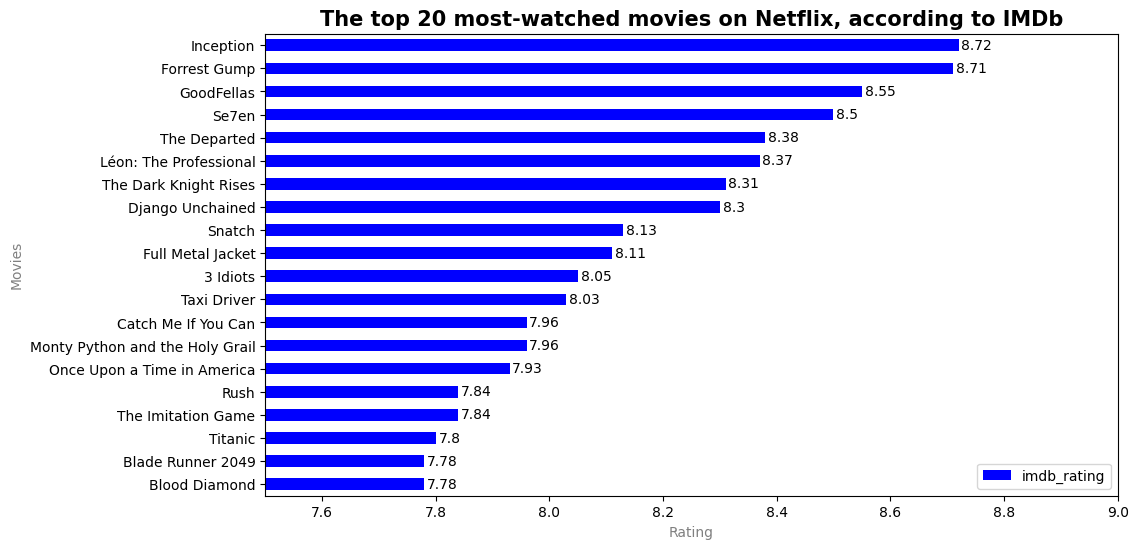

In [31]:
top20_movies['imdb_rating']=np.round(top20_movies['imdb_rating'], 2)
ax=top20_movies.iloc[::-1].plot(kind='barh', x='title', y='imdb_rating', color='blue', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('The top 20 most-watched movies on Netflix, according to IMDb', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=10, color='grey')
plt.ylabel('Movies', fontsize=10, color='grey')
plt.xlim(7.5, 9)
plt.show()

Applying the weighted rating formula to the shows dataset and filtering the top 20 shows.

Применяем формулу взвешенного рейтинга к набору данных shows и фильтруем 20 лучших телешоу.

In [32]:
shows1=shows.copy()
m=shows1['imdb_votes'].quantile(0.9)
c=shows1['imdb_score'].mean()
shows1['imdb_rating']=imdb_rating(shows1['imdb_votes'], shows1['imdb_score'], m, c)
top20_shows=shows1[rating_columns].sort_values(by='imdb_rating', ascending=False).head(20)
display(top20_shows)

,id,title,release_year,age_certification,genres,production_countries,imdb_votes,imdb_score,imdb_rating
40,ts4,Breaking Bad,2008,TV-MA,"Drama, Crime, Thriller",United States,1775990,9.5,9.452210
53,ts3371,Avatar: The Last Airbender,2005,TV-Y7,"Scifi, Animation, Action, Family, Fantasy",United States,303666,9.3,9.057180
217,ts20682,Attack on Titan,2013,TV-MA,"Action, Scifi, Animation, Horror, Drama, Fantasy",Japan,325381,9.0,8.796018
58,ts11313,DEATH NOTE,2006,TV-14,"Animation, Thriller, Scifi, Drama, Fantasy, Crime",Japan,309445,9.0,8.786390
3,ts20681,Seinfeld,1989,TV-PG,Comedy,United States,308824,8.9,8.694364
162,ts278,Black Mirror,2011,TV-MA,"Drama, Scifi, Thriller, European",United Kingdom,526383,8.8,8.680118
215,ts20110,Peaky Blinders,2013,TV-MA,"Crime, Drama, European",United Kingdom,511668,8.8,8.676851
1597,ts222333,Arcane,2021,TV-14,"Scifi, Action, Drama, Animation, Fantasy",United States,186899,9.0,8.664692
292,ts8,Better Call Saul,2015,TV-MA,"Drama, Crime",United States,438575,8.8,8.657566
319,ts36631,Narcos,2015,TV-MA,"Drama, Thriller, Crime",United States,410463,8.8,8.648438


Generating a horizontal bar chart to display the top 20 highest-rated TV shows.

Создание горизонтальной гистограммы для отображения 20 лучших телешоу с самым высоким рейтингом.

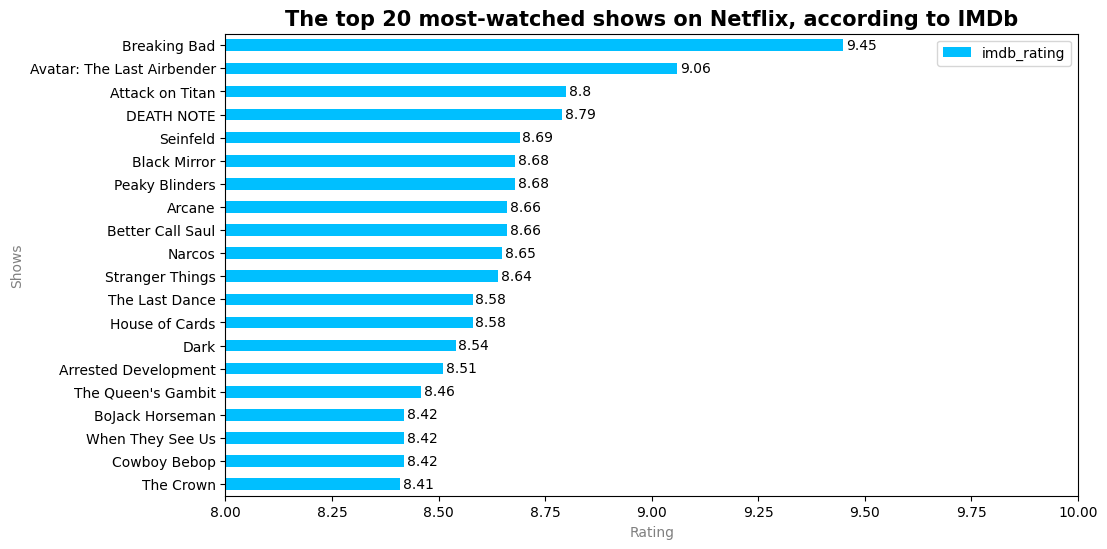

In [33]:
top20_shows['imdb_rating']=np.round(top20_shows['imdb_rating'], 2)
ax=top20_shows.iloc[::-1].plot(kind='barh', x='title', y='imdb_rating', color='deepskyblue', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('The top 20 most-watched shows on Netflix, according to IMDb', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=10, color='grey')
plt.ylabel('Shows', fontsize=10, color='grey')
plt.xlim(8, 10)
plt.show()

Creating a pie chart to visualize the distribution percentage between movies and shows in the dataset.

Создание круговой диаграммы для визуализации процентного распределения между фильмами и шоу в наборе данных.

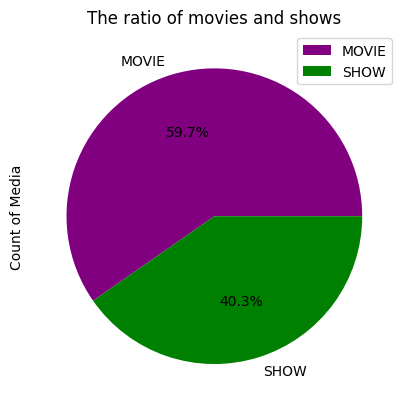

In [34]:
pie_df2=df2.groupby('type', as_index=False)['title'].count()
pie_df2.plot(kind='pie', y='title', labels=pie_df2['type'], autopct='%1.1f%%',
             colors=['purple', 'green'], ylabel='Count of Media', title='The ratio of movies and shows')
plt.show()

Grouping the movies dataset by release year to aggregate the movie count and average runtime.

Сгруппируйте набор данных о фильмах по годам выпуска, чтобы подсчитать количество фильмов и среднее время их просмотра.

In [35]:
analysis_every_year=movies.groupby('release_year', as_index=False)[['title', 'runtime']].agg(
    {'title': 'count', 'runtime': 'mean'})
analysis_every_year=analysis_every_year.rename(
    columns={'release_year': 'year', 'title': 'count_movies', 'runtime': 'average_runtime'})
display(analysis_every_year.sort_values(by=['count_movies', 'average_runtime'], ascending=False).head(20))

,year,count_movies,average_runtime
58,2020,413,95.380145
59,2021,412,99.191748
57,2019,393,100.129771
56,2018,376,99.539894
55,2017,269,99.479554
60,2022,184,97.266304
54,2016,174,99.160920
53,2015,106,107.896226
51,2013,89,107.022472
52,2014,88,109.056818


Extracting and sorting the unique list of release years to analyze the timeline.

Извлечение и сортировка уникального списка годов выпуска для анализа временной шкалы.

In [36]:
lst=analysis_every_year['year'].tolist()
lst.sort()
print(lst)

[1954, 1956, 1958, 1959, 1960, 1963, 1966, 1967, 1969, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


Grouping the yearly movie statistics into decades and calculating the aggregated metrics.

Группировка годовой статистики фильмов по десятилетиям и расчет агрегированных показателей.

In [37]:
def decades(df):
    return (df['year']//10*10).astype(str)+'s'
analysis_every_year['decade']=decades(analysis_every_year)
analysis_every_year['average_runtime']=np.round(analysis_every_year['average_runtime'], 2)
analysis_decades=analysis_every_year.groupby('decade', as_index=False)[['count_movies', 'average_runtime']].agg(
    {'count_movies': 'sum', 'average_runtime': 'mean'})
analysis_decades['average_runtime']=np.round(analysis_every_year['average_runtime'], 2)
display(analysis_decades)

,decade,count_movies,average_runtime
0,1950s,4,100.0
1,1960s,5,120.0
2,1970s,17,77.0
3,1980s,36,142.0
4,1990s,86,158.0
5,2000s,245,186.0
6,2010s,1660,117.0
7,2020s,1009,110.0


Building a dual subplot to show the number of movies (log-scale) and the trend of average movie runtime across decades.

Построение двойного вспомогательного графика, показывающего количество фильмов (логарифмическая шкала) и тенденцию средней продолжительности просмотра фильмов за десятилетия.

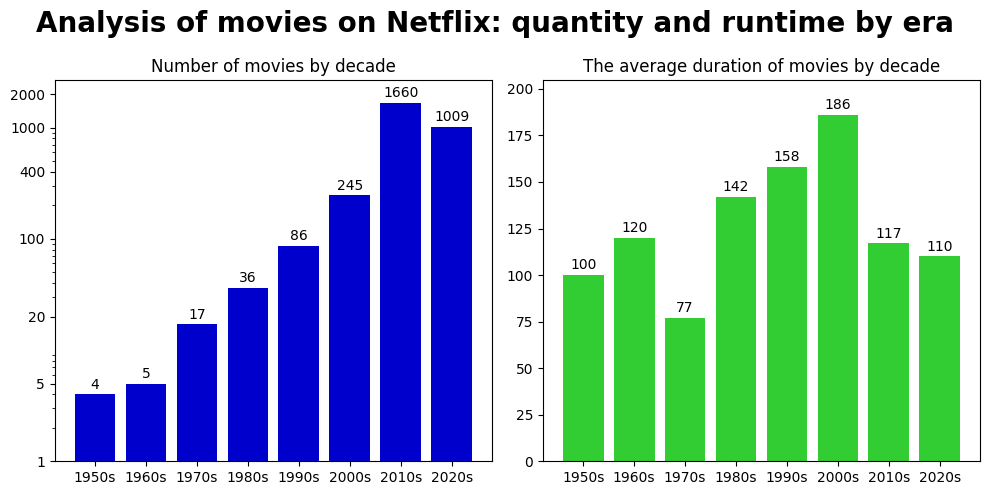

In [38]:
fig, (ax1, ax2)=plt.subplots(1, 2, figsize=(10, 5))
ax1.bar(analysis_decades['decade'], analysis_decades['count_movies'], color='mediumblue')
ax1.set_title('Number of movies by decade')
ax1.set_yscale('log')
ax1.set_ylim(1, analysis_decades['count_movies'].max()*1.6)
ax1.get_yaxis().set_major_formatter(ticker.ScalarFormatter())
ax1.set_yticks([1, 5, 20, 100, 400, 1000, 2000])
for container in ax1.containers:
    ax1.bar_label(container, padding=2)
ax2.bar(analysis_decades['decade'], analysis_decades['average_runtime'], color='limegreen')
ax2.set_title('The average duration of movies by decade')
ax2.set_ylim(0, analysis_decades['average_runtime'].max()*1.1)
for container in ax2.containers:
    ax2.bar_label(container, padding=2)
fig.suptitle('Analysis of movies on Netflix: quantity and runtime by era', fontsize=20, fontweight='bold')
plt.tight_layout()
plt.show()

Combining the actors dataset with the movie/show rating data to link actors with their project scores.

Объединение набора данных об актерах с данными о рейтингах фильмов / шоу позволяет связать актеров с оценками их проектов.

In [39]:
df3=pd.concat([movies1[['id', 'title', 'imdb_rating']], shows1[['id', 'title', 'imdb_rating']]])
actors1=pd.merge(actors, df3, on='id', how='left')
display(actors1.head())

,person_id,id,name,character,title,imdb_rating
0,3748,tm84618,Robert De Niro,Travis Bickle,Taxi Driver,8.033978
1,14658,tm84618,Jodie Foster,Iris Steensma,Taxi Driver,8.033978
2,7064,tm84618,Albert Brooks,Tom,Taxi Driver,8.033978
3,3739,tm84618,Harvey Keitel,Matthew 'Sport' Higgins,Taxi Driver,8.033978
4,48933,tm84618,Cybill Shepherd,Betsy,Taxi Driver,8.033978


Aggregating data by actor to find those with at least 4 projects, ranked by the average weighted rating.

Агрегируем данные по субъектам, чтобы найти тех, у кого есть как минимум 4 проекта, ранжированных по средневзвешенному рейтингу.

In [40]:
actors2=actors1.groupby('name')[['imdb_rating', 'name']].agg(
    {'imdb_rating': 'mean', 'name': 'count'})
actors2=actors2.rename(columns={'name': 'count'}).reset_index()
actors3=actors2[actors2['count']>=4].copy()
actors3['imdb_rating']=np.round(actors3['imdb_rating'], 2)
top20_actors=actors3.sort_values(by=['imdb_rating', 'count'], ascending=False).head(20)
display(top20_actors)

,name,imdb_rating,count
8010,Cillian Murphy,8.33,4
34445,Robert De Niro,7.85,5
40292,Tom Hardy,7.82,4
5324,Bob Odenkirk,7.79,4
23987,Leonardo DiCaprio,7.77,8
34638,Robin Wright,7.70,4
103,Aaron Paul,7.65,4
26350,Marion Cotillard,7.64,5
17189,James Russo,7.60,4
27945,Michael Caine,7.58,4


Creating a horizontal bar chart to show the top 20 actors with the highest average project ratings.

Создаем горизонтальную гистограмму, чтобы отобразить 20 лучших актеров с самыми высокими средними оценками проекта.

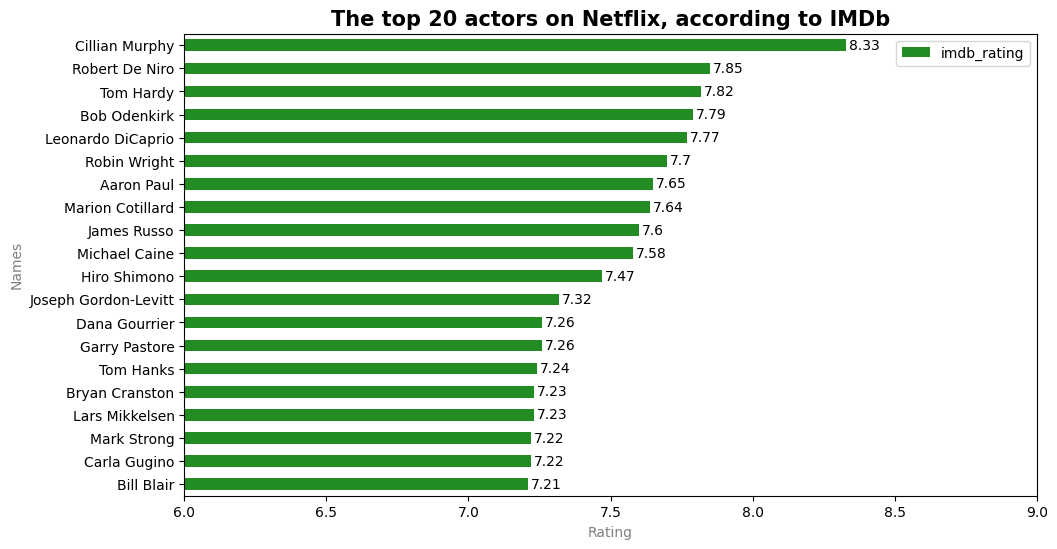

In [41]:
ax=top20_actors.iloc[::-1].plot(kind='barh', x='name', y='imdb_rating', color='forestgreen', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('The top 20 actors on Netflix, according to IMDb', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=10, color='grey')
plt.ylabel('Names', fontsize=10, color='grey')
plt.xlim(6, 9)
plt.show()

Aggregating data by director to find those with at least 4 projects, ranked by the average weighted rating.

Агрегируем данные по директорам, чтобы найти тех, у кого есть как минимум 4 проекта, ранжированных по средневзвешенному рейтингу.

In [42]:
directors1=pd.merge(directors, df3, on='id', how='left')
directors2=directors1.groupby('name')[['imdb_rating', 'name']].agg(
    {'imdb_rating': 'mean', 'name': 'count'})
directors2=directors2.rename(columns={'name': 'count'}).reset_index()
directors3=directors2[directors2['count']>=4].copy()
directors3['imdb_rating']=np.round(directors3['imdb_rating'], 2)
top20_directors=directors3.sort_values(by=['imdb_rating', 'count'], ascending=False).head(20)
display(top20_directors)

,name,imdb_rating,count
1714,Martin Scorsese,7.64,5
916,Guy Ritchie,7.57,4
1058,James Wan,6.81,4
2805,Vikramaditya Motwane,6.67,4
1298,Jung Jee-hyun,6.56,4
2855,Wilson Yip,6.53,5
980,Hong Jong-chan,6.52,5
760,Farhan Akhtar,6.49,4
2536,Song Hyun-wook,6.48,6
2714,Todd Phillips,6.48,4


Creating a horizontal bar chart to show the top 20 directors with the highest average project ratings.

Создание горизонтальной линейчатой диаграммы для отображения 20 лучших режиссеров с самыми высокими средними оценками проектов.

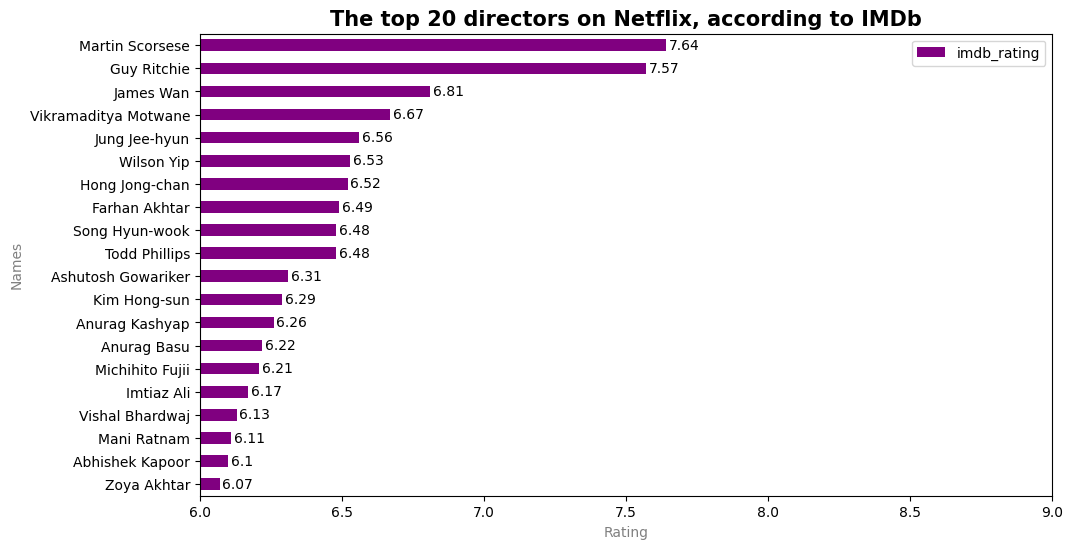

In [43]:
ax=top20_directors.iloc[::-1].plot(kind='barh', x='name', y='imdb_rating', color='purple', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('The top 20 directors on Netflix, according to IMDb', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=10, color='grey')
plt.ylabel('Names', fontsize=10, color='grey')
plt.xlim(6, 9)
plt.show()

Breaking down movies by production country and calculating weighted country ratings for countries with at least 15 movies.

Разбивка фильмов по странам производства и расчет взвешенных рейтингов стран для стран, в которых снято не менее 15 фильмов.

In [44]:
movies2=movies1[['id', 'title', 'production_countries', 'imdb_score', 'imdb_votes']].copy()
movies2['production_countries']=movies2['production_countries'].str.split(', ')
movies2=movies2.explode('production_countries')
movies2['score_x_votes']=movies2['imdb_score']*movies2['imdb_votes']
countries_movie=movies2.groupby('production_countries', as_index=False)[['title', 'score_x_votes', 'imdb_votes']].agg({
    'title': 'count', 'score_x_votes': 'sum', 'imdb_votes': 'sum'
})
countries_movie=countries_movie.rename(columns={'title': 'movies_count', 'production_countries': 'country'})
countries_movie=countries_movie[countries_movie['imdb_votes']>0]
countries_movie['mean_score']=countries_movie['score_x_votes']/countries_movie['imdb_votes']
countries_movie['votes_per_movie']=countries_movie['imdb_votes']/countries_movie['movies_count']
m=movies1['imdb_votes'].quantile(0.9)
c=movies1['imdb_score'].mean()
countries_movie['imdb_rating']=imdb_rating(countries_movie['votes_per_movie'], countries_movie['mean_score'], m, c)
countries_movie=countries_movie[countries_movie['movies_count']>=15]
group_columns1=['mean_score', 'votes_per_movie', 'imdb_rating']
countries_movie[group_columns1]=np.round(countries_movie[group_columns1], 2)
top20_cm=countries_movie.sort_values(by=['imdb_rating', 'movies_count'], ascending=False).head(20)
display(top20_cm)


,country,movies_count,score_x_votes,imdb_votes,mean_score,votes_per_movie,imdb_rating
93,United Kingdom,224,132066590.3,17503776,7.55,78141.86,6.77
94,United States,818,522637650.0,72048391,7.25,88078.72,6.65
27,Germany,97,29671038.4,4174080,7.11,43031.75,6.31
59,Netherlands,29,5692071.1,751915,7.57,25928.10,6.30
5,Australia,38,10585934.2,1513114,7.00,39818.79,6.24
25,France,175,29583435.8,4019180,7.36,22966.74,6.19
54,Mexico,71,7770050.7,1026312,7.57,14455.10,6.09
33,Hong Kong,33,3968420.4,546868,7.26,16571.76,6.07
14,Canada,138,24371809.0,3693053,6.60,26761.25,6.00
42,Italy,59,7403833.5,1076762,6.88,18250.20,6.00


Creating a horizontal bar chart to display the highest-rated production countries for movies.

Создание горизонтальной линейчатой диаграммы для отображения стран-производителей фильмов с самым высоким рейтингом.

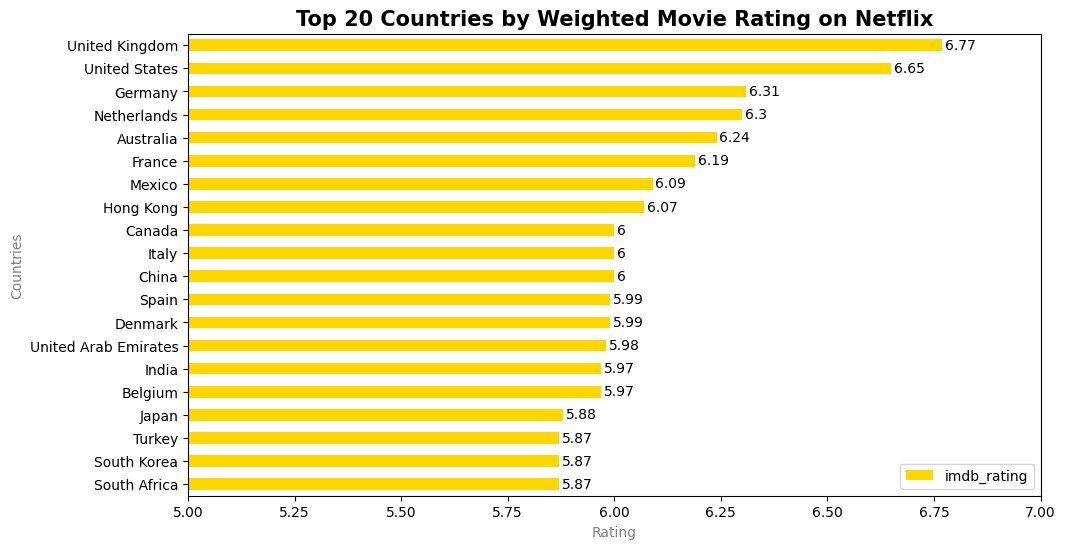

In [45]:
ax=top20_cm.iloc[::-1].plot(kind='barh', x='country', y='imdb_rating', color='gold', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Top 20 Countries by Weighted Movie Rating on Netflix', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=10, color='grey')
plt.ylabel('Countries', fontsize=10, color='grey')
plt.xlim(5, 7)
plt.show()

Breaking down shows by production country and calculating weighted country ratings for countries with at least 15 shows.

Разбивка показов по странам производства и расчет взвешенных рейтингов стран для стран, в которых было показано не менее 15 показов.

In [46]:
shows2=shows1[['id', 'title', 'production_countries', 'imdb_score', 'imdb_votes']].copy()
shows2['production_countries']=shows2['production_countries'].str.split(', ')
shows2=shows2.explode('production_countries')
shows2['score_x_votes']=shows2['imdb_score']*shows2['imdb_votes']
countries_shows=shows2.groupby('production_countries', as_index=False)[['title', 'score_x_votes', 'imdb_votes']].agg({
    'title': 'count', 'score_x_votes': 'sum', 'imdb_votes': 'sum'
})
countries_shows=countries_shows.rename(columns={'title': 'shows_count', 'production_countries': 'country'})
countries_shows=countries_shows[countries_shows['imdb_votes']>0]
countries_shows['mean_score']=countries_shows['score_x_votes']/countries_shows['imdb_votes']
countries_shows['votes_per_shows']=countries_shows['imdb_votes']/countries_shows['shows_count']
m=shows1['imdb_votes'].quantile(0.9)
c=shows1['imdb_score'].mean()
countries_shows['imdb_rating']=imdb_rating(countries_shows['votes_per_shows'], countries_shows['mean_score'], m, c)
countries_shows=countries_shows[countries_shows['shows_count']>=15]
group_columns1=['mean_score', 'votes_per_shows', 'imdb_rating']
countries_shows[group_columns1]=np.round(countries_shows[group_columns1], 2)
top20_cs=countries_shows.sort_values(by=['imdb_rating', 'shows_count'], ascending=False).head(20)
display(top20_cs)

,country,shows_count,score_x_votes,imdb_votes,mean_score,votes_per_shows,imdb_rating
60,United Kingdom,147,29832665.6,3622801,8.23,24644.90,7.28
61,United States,786,187852958.8,23309158,8.06,29655.42,7.27
16,Germany,34,4983724.2,602235,8.28,17712.79,7.15
25,Japan,169,17761071.7,2088578,8.50,12358.45,7.07
7,Canada,61,6069547.3,768981,7.89,12606.25,6.89
50,Spain,75,5763627.3,736074,7.83,9814.32,6.80
20,India,45,2436744.4,311862,7.81,6930.27,6.71
57,Turkey,22,1663847.8,226715,7.34,10305.23,6.68
49,South Korea,179,7723036.9,989948,7.80,5530.44,6.67
15,France,62,2511558.9,336162,7.47,5421.97,6.61


Creating a horizontal bar chart to display the highest-rated production countries for shows.

Создание горизонтальной линейчатой диаграммы для отображения стран-производителей с самым высоким рейтингом показов.

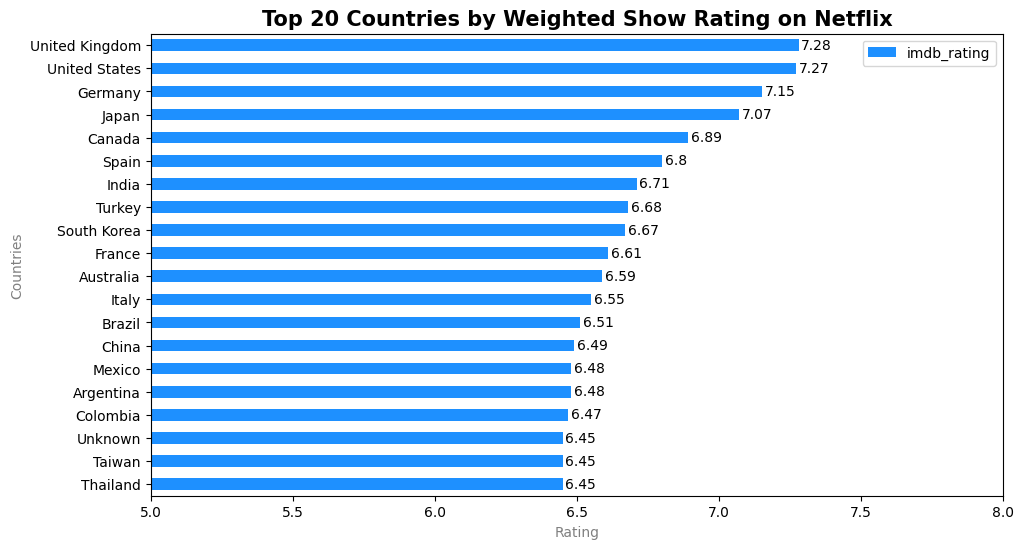

In [47]:
ax=top20_cs.iloc[::-1].plot(kind='barh', x='country', y='imdb_rating', color='dodgerblue', figsize=(11, 6))
for container in ax.containers:
    ax.bar_label(container, padding=2)
plt.title('Top 20 Countries by Weighted Show Rating on Netflix', fontsize=15, fontweight='bold')
plt.xlabel('Rating', fontsize=10, color='grey')
plt.ylabel('Countries', fontsize=10, color='grey')
plt.xlim(5, 8)
plt.show()

Generating a final summary table showing total unique counts for movies, shows, genres, countries, actors, and directors.

Создание итоговой сводной таблицы, показывающей общее количество уникальных просмотров фильмов, шоу, жанров, стран, актеров и режиссеров.

In [48]:
info_beta1=pd.Series(df2['genres'].str.split(', '))
info_beta2=pd.Series(df2['production_countries'].str.split(', '))
info=pd.Series({
    'count_movies': movies['title'].count(),
    'count_shows': shows['title'].count(),
    'count_genres': info_beta1.explode().nunique(),
    'count_countries': info_beta2.explode().nunique(),
    'count_actors': actors['name'].nunique(),
    'count_directors': directors['name'].nunique()
}).astype('int32')
display(info)

,0
count_movies,3062
count_shows,2068
count_genres,20
count_countries,105
count_actors,43572
count_directors,2966


Exporting the final cleaned DataFrames (movies, shows, actors, directors) into separate CSV files.

Экспорт окончательно очищенных фрагментов данных (фильмы, шоу, актеры, режиссеры) в отдельные CSV-файлы.

In [49]:
movies.to_csv('netflix_movies_analysis.csv', index=False)
shows.to_csv('netflix_shows_analysis.csv', index=False)
actors.to_csv('netflix_actors_analysis.csv', index=False)
directors.to_csv('netflix_directors_analysis.csv', index=False)